<a href="https://colab.research.google.com/github/MontenegroRafael/Analise-de-Dados/blob/main/Desafio%20Extra.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1° Intalar Bibliotecas abaixo.

In [1]:
# Código utilizado para instalar as bibiotecas: kagglehub e o plotly.
#!pip install kagglehub plotly -q
#!pip install plotly

2° Importar as bibliotecas que serão utlizadas.

In [2]:
# Importando bibliotecas para uso na analise do banco de dados.
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import plotly.subplots
import warnings
import os
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore") # para ignorar mensagens geradas pelo Python

3° Executa o carregamento do dataset para analise.

In [3]:
# Codigo utilizado para carregar o dataset dentro do Google Colab.
import kagglehub

# Download latest version
path = kagglehub.dataset_download("vivek468/superstore-dataset-final")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
Path to dataset files: /kaggle/input/superstore-dataset-final


4° Configura os aspecto visual das tabelas.

In [4]:
# Configurações visuais padrão para gráficos matplotlib/seaborn
sns.set_theme(style='whitegrid' , palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12

In [5]:
os.listdir(path)

['Sample - Superstore.csv']

5° Faz a junção do path para o arquivo csv.
    e executa o comando "df.head()" para visualizar o dataset.

In [6]:
arquivo_csv = os.path.join(path, 'Sample - Superstore.csv')
df = pd.read_csv(arquivo_csv, encoding='latin-1', dtype={'Postal Code': str})
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


6° Executa o comando " df.tail()" para verificar como esta o final da lista e comprovar se os dados estão dentro do esperado.

In [7]:
df.tail()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
9989,9990,CA-2014-110422,1/21/2014,1/23/2014,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.248,3,0.2,4.1028
9990,9991,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.960,2,0.0,15.6332
9991,9992,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.576,2,0.2,19.3932
9992,9993,CA-2017-121258,2/26/2017,3/3/2017,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.600,4,0.0,13.3200
9993,9994,CA-2017-119914,5/4/2017,5/9/2017,Second Class,CC-12220,Chris Cortes,Consumer,United States,Westminster,...,92683,West,OFF-AP-10002684,Office Supplies,Appliances,"Acco 7-Outlet Masterpiece Power Center, Wihtou...",243.160,2,0.0,72.9480


7° Executa o comando "df.info()" para verificar a existência de valores nulos ou tipos de dados fora do esperado.

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   object 
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

8° Executa o comando "df.describe()" para analizar valores de medias e medianas e verificar a existencia de offlines e estudar os quartis para extração de informação.

In [9]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


9° Criar um dicionario que traduza os termos para portugues e facilite o entendimento.

In [10]:
tradução_colunas = {
    'Row ID': 'id_Linha',
    'Order ID': 'id_Pedido',
    'Order Date': 'data_Pedido',
    'Ship Date': 'data_Envio',
    'Ship Mode': 'modo_Envio',
    'Customer ID': 'id_Cliente',
    'Customer Name': 'nome_Cliente',
    'Segment': 'segmento',
    'Country': 'pais',
    'City': 'cidade',
    'State': 'estado',
    'Postal Code': 'cep',
    'Region': 'regiao',
    'Product ID': 'id_Produto',
    'Category': 'categoria',
    'Sub-Category': 'subcategoria',
    'Product Name': 'nome_Produto',
    'Sales': 'vendas',
    'Quantity': 'quantidade',
    'Discount': 'desconto',
    'Profit': 'lucro'
}


10° Executa o comando abaixo para renomear as colunas conforme a biblioteca criada.

In [11]:
df=df.rename(columns=tradução_colunas)
df.columns

Index(['id_Linha', 'id_Pedido', 'data_Pedido', 'data_Envio', 'modo_Envio',
       'id_Cliente', 'nome_Cliente', 'segmento', 'pais', 'cidade', 'estado',
       'cep', 'regiao', 'id_Produto', 'categoria', 'subcategoria',
       'nome_Produto', 'vendas', 'quantidade', 'desconto', 'lucro'],
      dtype='object')

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5899 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_Linha      5899 non-null   int64         
 1   id_Pedido     5899 non-null   object        
 2   data_Pedido   5899 non-null   datetime64[ns]
 3   data_Envio    5899 non-null   datetime64[ns]
 4   modo_Envio    5899 non-null   object        
 5   id_Cliente    5899 non-null   object        
 6   nome_Cliente  5899 non-null   object        
 7   segmento      5899 non-null   object        
 8   pais          5899 non-null   object        
 9   cidade        5899 non-null   object        
 10  estado        5899 non-null   object        
 11  cep           5899 non-null   object        
 12  regiao        5899 non-null   object        
 13  id_Produto    5899 non-null   object        
 14  categoria     5899 non-null   object        
 15  subcategoria  5899 non-null   object       

11° Executar comando para retirar linhas duplicadas.
---
 o comando "df.drop_duplicates(inplace=True)" copia a linha duplicada no proprio dataset, desta forma se tiver alguma linha duplicada quando executasse o comando "len(df)" a resposta seria maior que o numero de linhas que apareceu no comando "df.tail()".


In [12]:
df.drop_duplicates(inplace=True)

In [13]:
len(df)

9994

12° Transforma o tipo de objeto para datetime dos dados - data_Pedido e data_Envio. Facilitando o tratamento dentro do código.

In [14]:
df['data_Pedido'] = pd.to_datetime(df['data_Pedido'])
df['data_Envio'] = pd.to_datetime(df['data_Envio'])

13° Criar algumas colunas para realizar enalise mais direcionadas.

In [15]:
# Extração de componentes de data
df['ano'] = df['data_Pedido'].dt.year  # extraindo o ano como base na "data_Pedido"
df['mes'] = df['data_Pedido'].dt.month # extraindo o Mês
df['dia'] = df['data_Pedido'].dt.day # extraindo o dia
df['nome-mes'] = df['data_Pedido'].dt.strftime('%b')  # Jan, Fev, ...

# Dias de entrega: quanto tempo levou para o cliente receber o produto?
df['dias_entrega'] = (df['data_Envio'] - df['data_Pedido']).dt.days


In [16]:
# Margem de lucro por transação ( em %) 💰
df['margem_lucro'] = np.where(
    df['vendas'] != 0, # tratativa "!=0" para vendas ser diferente de zero
    ((df['lucro'] / df['vendas']) * 100).round(2), # ".round(2)" duas casa decimas
    0
)

In [17]:
df['margem_lucro'].head()

,margem_lucro
0,16.00
1,30.00
2,47.00
3,-40.00
4,11.25


In [18]:
# Tradução das categorias para português
df['categoria'] = df['categoria'].map({
    'Office Supplies': 'Papelaria',
    'Furniture': 'Móveis',
    'Technology': 'Tecnologia'
})

# Tradução das sub-categorias para português
df['subcategoria'] = df['subcategoria'].map({
    'Bookcases': 'Estantes',
    'Chairs': 'Cadeiras',
    'Tables': 'Mesas',
    'Furnishings': 'Mobiliário',
    'Appliances': 'Eletrodomésticos',
    'Art': 'Arte',
    'Binders': 'Fichários',
    'Envelopes': 'Envelipes',
    'Fasteners': 'Grampos',
    'Labels': 'Etiquetas',
    'Paper': 'Papel',
    'Storage': 'Armazenamento',
    'Supplies': 'Suprimentos',
    'Accessories': 'Acessórios',
    'Copiers': 'Copiadoras',
    'Machines': 'Máquinas',
    'Phones': 'Telefones'
})

# Tradução dos segmentos para português
df['segmento'] = df['segmento'].map({
    'Consumer': 'Consumidor',
    'Corporate': 'Corporativo',
    'Home Office': 'Escritório'
})

# Tradução das regiões para português
df['regiao'] = df['regiao'].map({
    'South': 'Sul',
    'West': 'Oeste',
    'Central': 'Centro-Oeste',
    'East': 'Leste'
})

# Tradução dos modos de envio
df['modo_Envio'] = df['modo_Envio'].map({
    'Standard Class': 'Padrão',
    'Same Day': 'Mesmo Dia',
    'First Class': 'Primeira Classe',
    'Second Class': 'Segunda Classe'

})

# Filtrar apenas os anos de 2016 e 2017
linhas_antes = len(df)

df = df[df['ano'].isin([2016, 2017])].copy()

linhas_depois = len(df)

print(f'Linhas antes do filtro : {linhas_antes:,}')
print(f'Linhas após o filtro : {linhas_depois:,}')
print(f'Linhas removidas : {linhas_antes - linhas_depois:,}')
print()

# Verifica a distribuição por ano e por mês após o filtro
dist = df.groupby(['ano', 'mes']).size().reset_index(name='registros')
print('Registros por mês (2016 e 2017):')
print(dist.pivot(index='mes', columns='ano', values='registros').fillna(0).astype(int).to_string())

Linhas antes do filtro : 9,994
Linhas após o filtro : 5,899
Linhas removidas : 4,095

Registros por mês (2016 e 2017):
ano  2016  2017
mes            
1      89   155
2      83   107
3     163   238
4     170   203
5     225   242
6     199   245
7     201   226
8     176   218
9     363   459
10    196   298
11    370   459
12    352   462


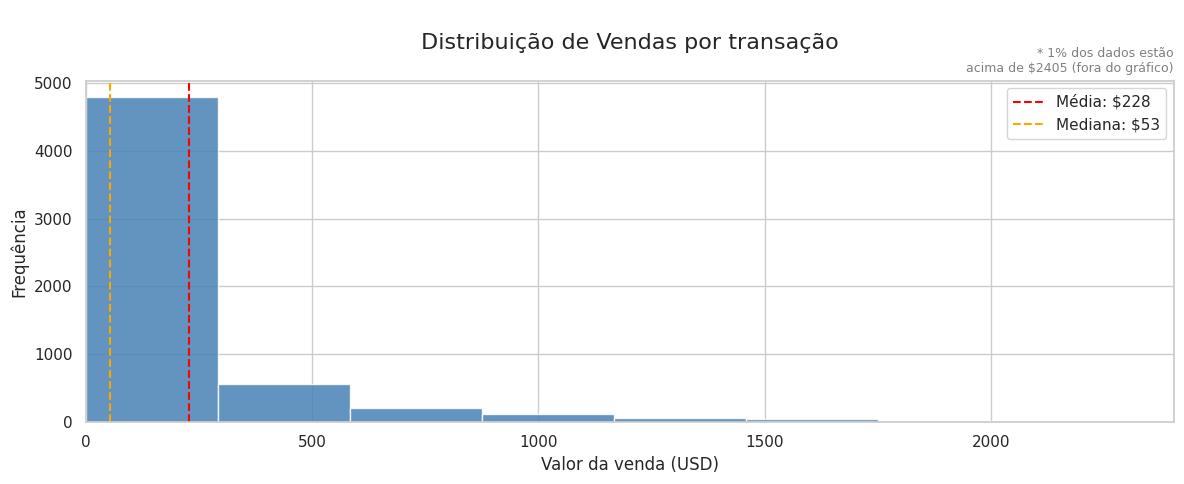


📊Estatísticas de Vendas:
count     $5,899.00
mean        $227.57
std         $622.99
min           $0.44
25%          $17.48
50%          $53.42
75%         $206.05
max      $17,499.95
Name: vendas, dtype: object


In [19]:
# Distribuição de Vendas
# Usamos o percentil 95 como limite do eixo X para focar onde está a maioria dos dados
# Os outliers existem, mas não precisam distorcer a visualização

# Define o limite do eixo X para o gráfico, cobrindo 99% dos dados de vendas.
p95_vendas = df['vendas'].quantile(0.99) # valor que cobre 95% dos dados
media_vendas = df['vendas'].mean() # média dos dados
mediana_vendas = df['vendas'].median() # mediana dos dados

fig, ax = plt.subplots(figsize=[12,5]) # Dimenção do dataframe

ax.hist(df['vendas'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(media_vendas, color='red', linestyle='--', linewidth=1.5, label=f'Média: ${media_vendas:.0f}')
ax.axvline(mediana_vendas, color='orange', linestyle='--', linewidth=1.5, label=f'Mediana: ${mediana_vendas:.0f}')

ax.set_xlim(0, p95_vendas)
ax.set_title('\n Distribuição de Vendas por transação \n', fontsize=16)
ax.set_xlabel('Valor da venda (USD)')
ax.set_ylabel('Frequência')
ax.legend()

pct_outlier = (df['vendas'] > p95_vendas).mean() * 100
ax.text(1, 1.1, f'* {pct_outlier:.0f}% dos dados estão\nacima de ${p95_vendas:.0f} (fora do gráfico)',
        transform=ax.transAxes, ha='right', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()

print('\n📊Estatísticas de Vendas:')

print(df['vendas'].describe().apply(lambda x: f'${x:,.2f}'))

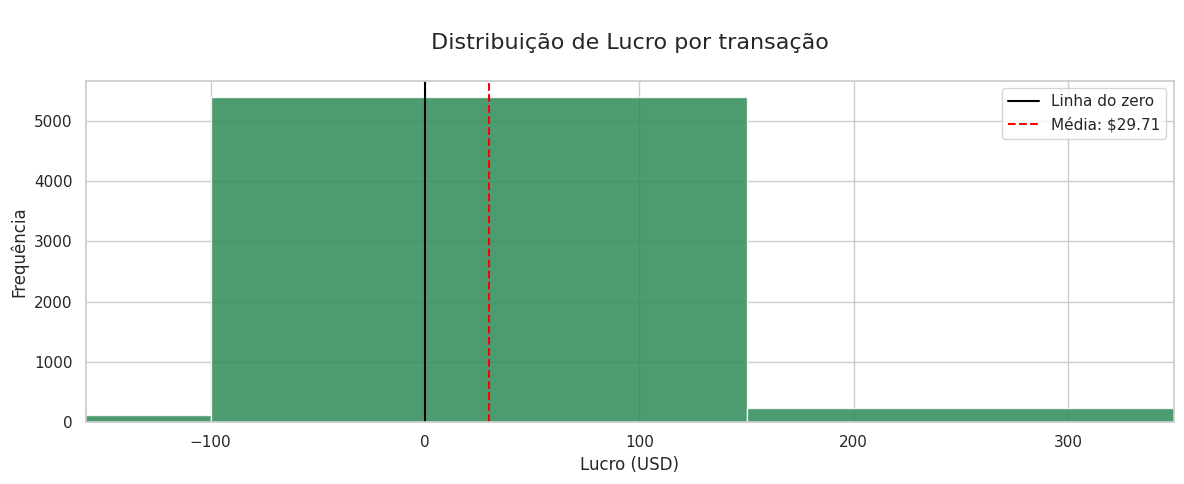

⚠️ 18.6% das transações tiveram lucro NEGATIVO (Prejuizo)
✔️ 81.4% das transações tiveram lucro POSITIVO (Lucro)


In [20]:
# Distribuição de Lucro

p02_lucro = df['lucro'].quantile(0.02)
p98_lucro = df['lucro'].quantile(0.98)
media_lucro = df['lucro'].mean()

fig, ax = plt.subplots(figsize=(12,5))

ax.hist(df['lucro'], bins=60, color='seagreen', edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', linestyle='-', linewidth=1.5, label='Linha do zero')
ax.axvline(media_lucro, color='red', linestyle='--', linewidth=1.5, label=f'Média: ${media_lucro:.2f}')

ax.set_xlim(p02_lucro, p98_lucro)
ax.set_title('\n Distribuição de Lucro por transação \n', fontsize=16)
ax.set_xlabel('Lucro (USD)')
ax.set_ylabel('Frequência')
ax.legend()

plt.tight_layout()
plt.show()

pct_prejuizo = (df['lucro'] < 0).mean() * 100
print(f'⚠️ {pct_prejuizo:.1f}% das transações tiveram lucro NEGATIVO (Prejuizo)')
print(f'✔️ {100 - pct_prejuizo:.1f}% das transações tiveram lucro POSITIVO (Lucro)')




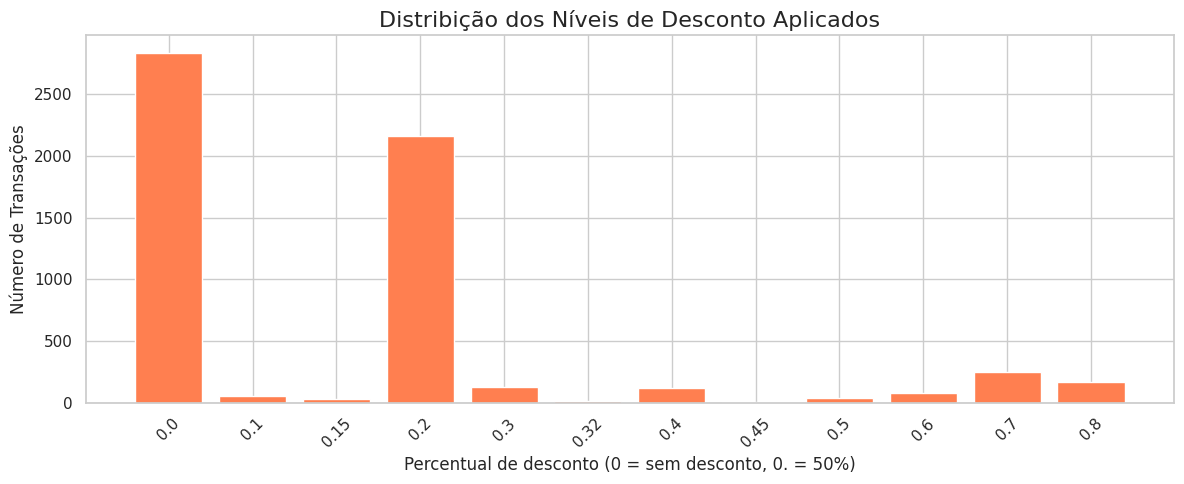


📊 48.1% das transações não tiveram desconto aplicado
 Desconto médio aplicado: 30.0% (apenas quando há desconto)


In [21]:
# Distribuição de descontos
# O desconto vai de 0 (sem desconto) a 1 (100% de desconto)

fig, ax = plt.subplots(figsize=(12,5))

contagem_desconto = df['desconto'].value_counts().sort_index()
ax.bar(contagem_desconto.index.astype(str), contagem_desconto.values, color='coral', edgecolor='white')
ax.set_title('Distribição dos Níveis de Desconto Aplicados', fontsize=16)
ax.set_xlabel('Percentual de desconto (0 = sem desconto, 0. = 50%)')
ax.set_ylabel('Número de Transações')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

sem_desconto = (df['desconto']== 0).mean() * 100
print(f'\n📊 {sem_desconto:.1f}% das transações não tiveram desconto aplicado')
print(f' Desconto médio aplicado: {df[df["desconto"] > 0]['desconto'].mean() * 100:.1f}% (apenas quando há desconto)')

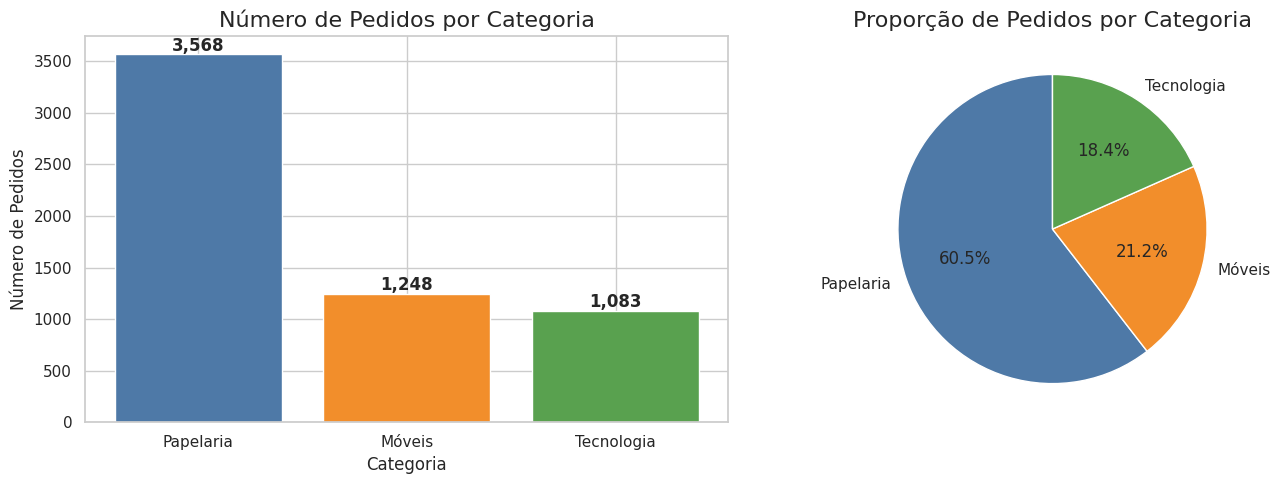

In [22]:
# Distribuição por Categoria de Produto
fig, axes = plt.subplots(1,2,figsize=(14,5))

contagem_cat = df['categoria'].value_counts()

# Gráfico de barras
axes[0].bar(contagem_cat.index, contagem_cat.values, color=['#4e79a7', '#f28e2b', '#59a14f'], edgecolor='white')
axes[0].set_title('Número de Pedidos por Categoria', fontsize=16)
axes[0].set_xlabel('Categoria')
axes[0].set_ylabel('Número de Pedidos')
for i, v in enumerate(contagem_cat.values):
    axes[0].text(i, v + 30, f'{v:,}', ha='center', fontweight='bold')

# Gráfico de Pizza
axes[1].pie(contagem_cat.values, labels=contagem_cat.index, autopct='%1.1f%%',
            colors=['#4e79a7', '#f28e2b', '#59a14f'], startangle=90)
axes[1].set_title('Proporção de Pedidos por Categoria', fontsize=16)

plt.tight_layout()
plt.show()

In [23]:
# Distribuição por Segmento de Cliente
contagem_seg = df['segmento'].value_counts()

fig = px.bar(
    x=contagem_seg.index,
    y=contagem_seg.values,
    title='Número de Pedidos por Segmento de Cliente',
    labels={'x': 'Segmento', 'y': 'Número de Pedidos'},
    color=contagem_seg.index,
    color_discrete_sequence=px.colors.qualitative.Set2,
    text=contagem_seg.values
)
fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

In [24]:
# Vendas e Lucro por Categoria
resumo_cat = df.groupby('categoria').agg(
    total_vendas=('vendas', 'sum'),
    total_lucro=('lucro', 'sum')
).reset_index().sort_values('total_vendas', ascending=False)

fig = make_subplots(rows=1, cols=2, subplot_titles=['Total de Vendas por Categoria', 'Total de Lucro por Categoria'])

cores = ['#4e79a7', '#f28e2b', '#59a14f']

fig.add_trace(
    go.Bar(x=resumo_cat['categoria'], y=resumo_cat['total_vendas'],
           marker_color=cores, text=resumo_cat['total_vendas'].apply(lambda x: f'${x:,.0f}'),
           textposition='outside', name='Vendas'),
    row=1, col=1
)

fig.add_trace(
    go.Bar(x=resumo_cat['categoria'], y=resumo_cat['total_lucro'],
           marker_color=cores, text=resumo_cat['total_lucro'].apply(lambda x: f'${x:,.0f}'),
           textposition='outside', name='Lucro'),
    row=1, col=2
)

In [25]:
fig = px.scatter(
    df.sample(min(2000, len(df)), random_state=42), # usa amostra para não sobrecarregar o gráfico
    x='desconto',
    y='lucro',
    color='categoria',
    title='Relação entre Desconto e Lucro por Transação',
    labels={'desconto': 'Desconto aplicado', 'lucro': 'Lucro (USD)'},
    opacity=0.5,
    trendline_scope='overall',
    color_discrete_sequence=px.colors.qualitative.Set1
)

fig.add_hline(y=0, line_dash='dash', line_color='black', annotation_text='Linha do zero (lucro/prejuízo)')
fig.update_layout(height=500)
fig.show()

In [27]:
# Lucro por Segmento de Cliente
resumo_seg = df.groupby('segmento').agg(
    total_vendas=('vendas', 'sum'),
    total_lucro=('lucro', 'sum'),
    mergem_media=('margem_lucro','mean')
).reset_index().round(2)

resumo_seg['margem_pct'] = resumo_seg['mergem_media'].apply(lambda x: f'{x:.1f}%')

fig = px.bar(
    resumo_seg,
    x='segmento',
    y='total_lucro',
    color='segmento',
    title='Lucro Total por Segmento de Cliente',
    labels={'segmento': 'Segmento', 'total_lucro': 'Lucro Total (USD)'},
    text=resumo_seg['total_lucro'].apply(lambda x: f'${x:,.0f}'),
    color_discrete_sequence=px.colors.qualitative.Set2
)

fig.update_traces(textposition='outside')
fig.update_layout(showlegend=False)
fig.show()

display(resumo_seg[['segmento', 'total_vendas', 'total_lucro', 'margem_pct']].rename(columns={
    'segmento': 'Segmento', 'total_vendas': 'Vendas (USD)',
    'total_lucro': 'Lucro (USD)','margem_pct': 'Margem Média'
    }))

,Segmento,Vendas (USD),Lucro (USD),Margem Média
0,Consumidor,628768.60,81339.19,12.6%
1,Corporativo,448954.19,57777.53,11.2%
2,Escritório,264698.07,36117.72,12.9%


In [29]:
lucro_subcat = df.groupby('subcategoria')['lucro'].sum().sort_values(ascending=True).reset_index() # faz um agrupamento somando por lucro.

# Define cor vermelha para prejuízo e verde para lucro positivo
lucro_subcat['cor'] = lucro_subcat['lucro'].apply(lambda x: '#d62728' if x < 0 else '#2ca02c')

fig = go.Figure(go.Bar(
    x=lucro_subcat['lucro'],
    y=lucro_subcat['subcategoria'],
    orientation='h',
    marker_color=lucro_subcat['cor'],
    text=lucro_subcat['lucro'].apply(lambda x: f'${x:,.0f}'),
    textposition='outside'
))

fig.add_vline(x=0, line_width=1.5, line_color='black')
fig.update_layout(
    title='Lucro Total por Subcategoria (vermelho = prejuízo)',
    xaxis_title='Lucro Total (USD)',
    yaxis_title='',
    height=600
)
fig.show()

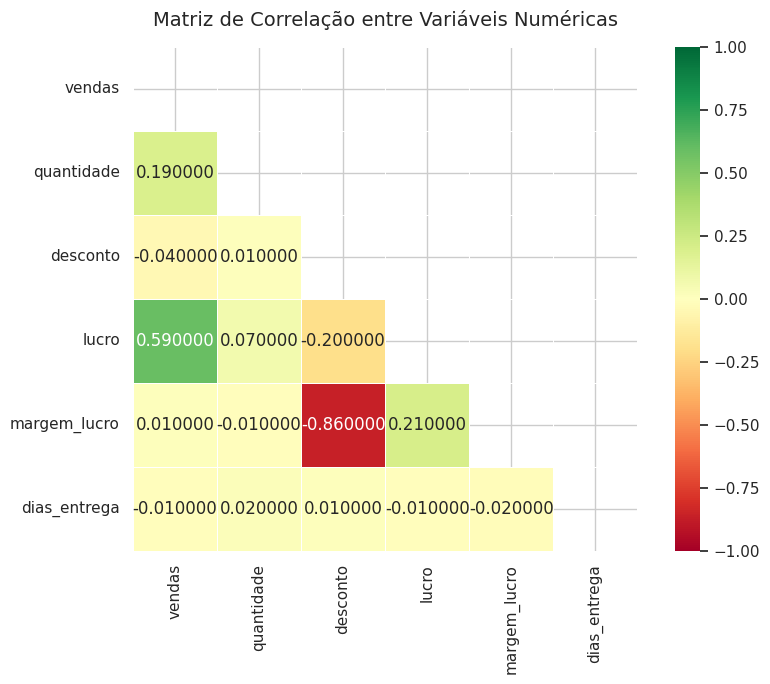

In [33]:
# Corelação de Desconto versus Lucro
colunas_numericas = ['vendas', 'quantidade', 'desconto', 'lucro', 'margem_lucro', 'dias_entrega']
matriz_corr = df[colunas_numericas].corr().round(2)

# Heatmap de cerrelação
fig, ax = plt.subplots(figsize=(9,7))

mask = np.triu(np.ones_like(matriz_corr, dtype=bool)) # máscara para ixibir apenas metade
sns.heatmap(
    matriz_corr,
    annot=True,
    fmt='2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1,
    vmax=1,
    mask=mask,
    square=True,
    linewidths=0.5,
    ax=ax
    )

ax.set_title('Matriz de Correlação entre Variáveis Numéricas', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Destaca a correlação mais relevante
corr_desc_lucro = matriz_corr.loc['desconto', 'lucro']

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5899 entries, 0 to 9993
Data columns (total 28 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id_Linha      5899 non-null   int64         
 1   id_Pedido     5899 non-null   object        
 2   data_Pedido   5899 non-null   datetime64[ns]
 3   data_Envio    5899 non-null   datetime64[ns]
 4   modo_Envio    5899 non-null   object        
 5   id_Cliente    5899 non-null   object        
 6   nome_Cliente  5899 non-null   object        
 7   segmento      5899 non-null   object        
 8   pais          5899 non-null   object        
 9   cidade        5899 non-null   object        
 10  estado        5899 non-null   object        
 11  cep           5899 non-null   object        
 12  regiao        5899 non-null   object        
 13  id_Produto    5899 non-null   object        
 14  categoria     5899 non-null   object        
 15  subcategoria  5899 non-null   object       

In [42]:
# Cria a coluna de classificados de outlier antes de exportar
Q1 = df['vendas'].quantile(0.25)
Q3 = df['vendas'].quantile(0.75)
IQR = Q3 - Q1
limite_sup = Q3 + 1.5 * IQR

df['porte_pedido'] = df['vendas'].gt(limite_sup).map({
    False: 'Pedido Normal',
    True: 'Pedido Alto Valor'
})


# Seleciona as colunas para o dashboard
colunas_dashboard = [
    'id_Pedido', 'data_Pedido', 'ano', 'mes', 'nome-mes',
    'segmento', 'regiao', 'estado', 'cidade',
    'categoria', 'subcategoria', 'nome_Produto',
    'modo_Envio', 'dias_entrega',
    'vendas', 'quantidade', 'desconto', 'lucro', 'margem_lucro',
    'porte_pedido'
]

df_dashboard = df[colunas_dashboard].copy()

# Salva o arquivo CSV
df_dashboard.to_csv('superstore_dashboard.csv', index=False)

print(f' Arquivo exportado: superstore_dashboard.csv')
print(f' Dimensões: {df_dashboard.shape[0]:,} linhas x {df_dashboard.shape[1]} colunas')
print()
print('Colunas incluidas no Dashboard:')
for col in colunas_dashboard:
    print(f' - {col}')

 Arquivo exportado: superstore_dashboard.csv
 Dimensões: 5,899 linhas x 20 colunas

Colunas incluidas no Dashboard:
 - id_Pedido
 - data_Pedido
 - ano
 - mes
 - nome-mes
 - segmento
 - regiao
 - estado
 - cidade
 - categoria
 - subcategoria
 - nome_Produto
 - modo_Envio
 - dias_entrega
 - vendas
 - quantidade
 - desconto
 - lucro
 - margem_lucro
 - porte_pedido


In [43]:
# Para fazer o Download do arquivo .CSV

from google.colab import files
files.download('superstore_dashboard.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>